# Import Library

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# import machine learning libraries
from sklearn import svm
from keras.layers import Dense, BatchNormalization, Dropout, LSTM
from keras.models import Sequential
from keras import callbacks
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score

ModuleNotFoundError: No module named 'tensorflow'

# Membaca dan Menampilkan Dataset

In [3]:
df = pd.read_csv("heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


# Visualisasi Distribusi dari VariableTarget

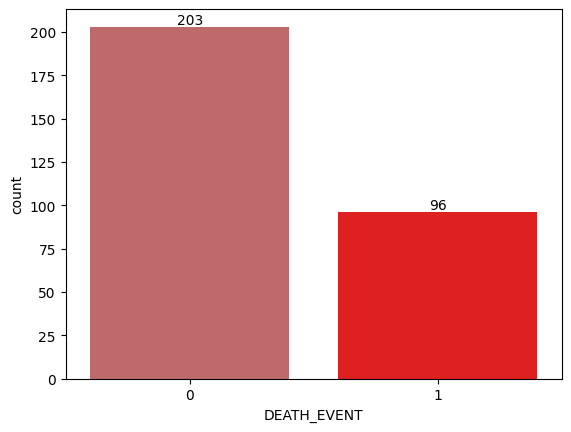

In [5]:
# cols = ["#CD5C5C", "#FF0000"]
# ax = sns.countplot(x=df["DEATH_EVENT"], palette=cols)
# ax.bar_label(ax.containers[0])

# Warna untuk setiap kategori
cols = ["#CD5C5C", "#FF0000"]

# Membuat countplot
ax = sns.countplot(x=df["DEATH_EVENT"], hue=df["DEATH_EVENT"], palette=cols, legend=False)

# Menambahkan label ke setiap bar
for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Cek Missing Values

In [6]:
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


## Cek Jumlah Data dan Kolom

In [7]:
df.shape

(299, 13)

In [8]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


# Melakukan Analisis Univariate untuk Deskripsi Statistikal dan Memahami Dispersi Data

In [9]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


# Melakukan Analisis Bivariat dengan Memeriksa Matriks Korelasi Semua Fitur Menggunakan Heatmap

<Axes: >

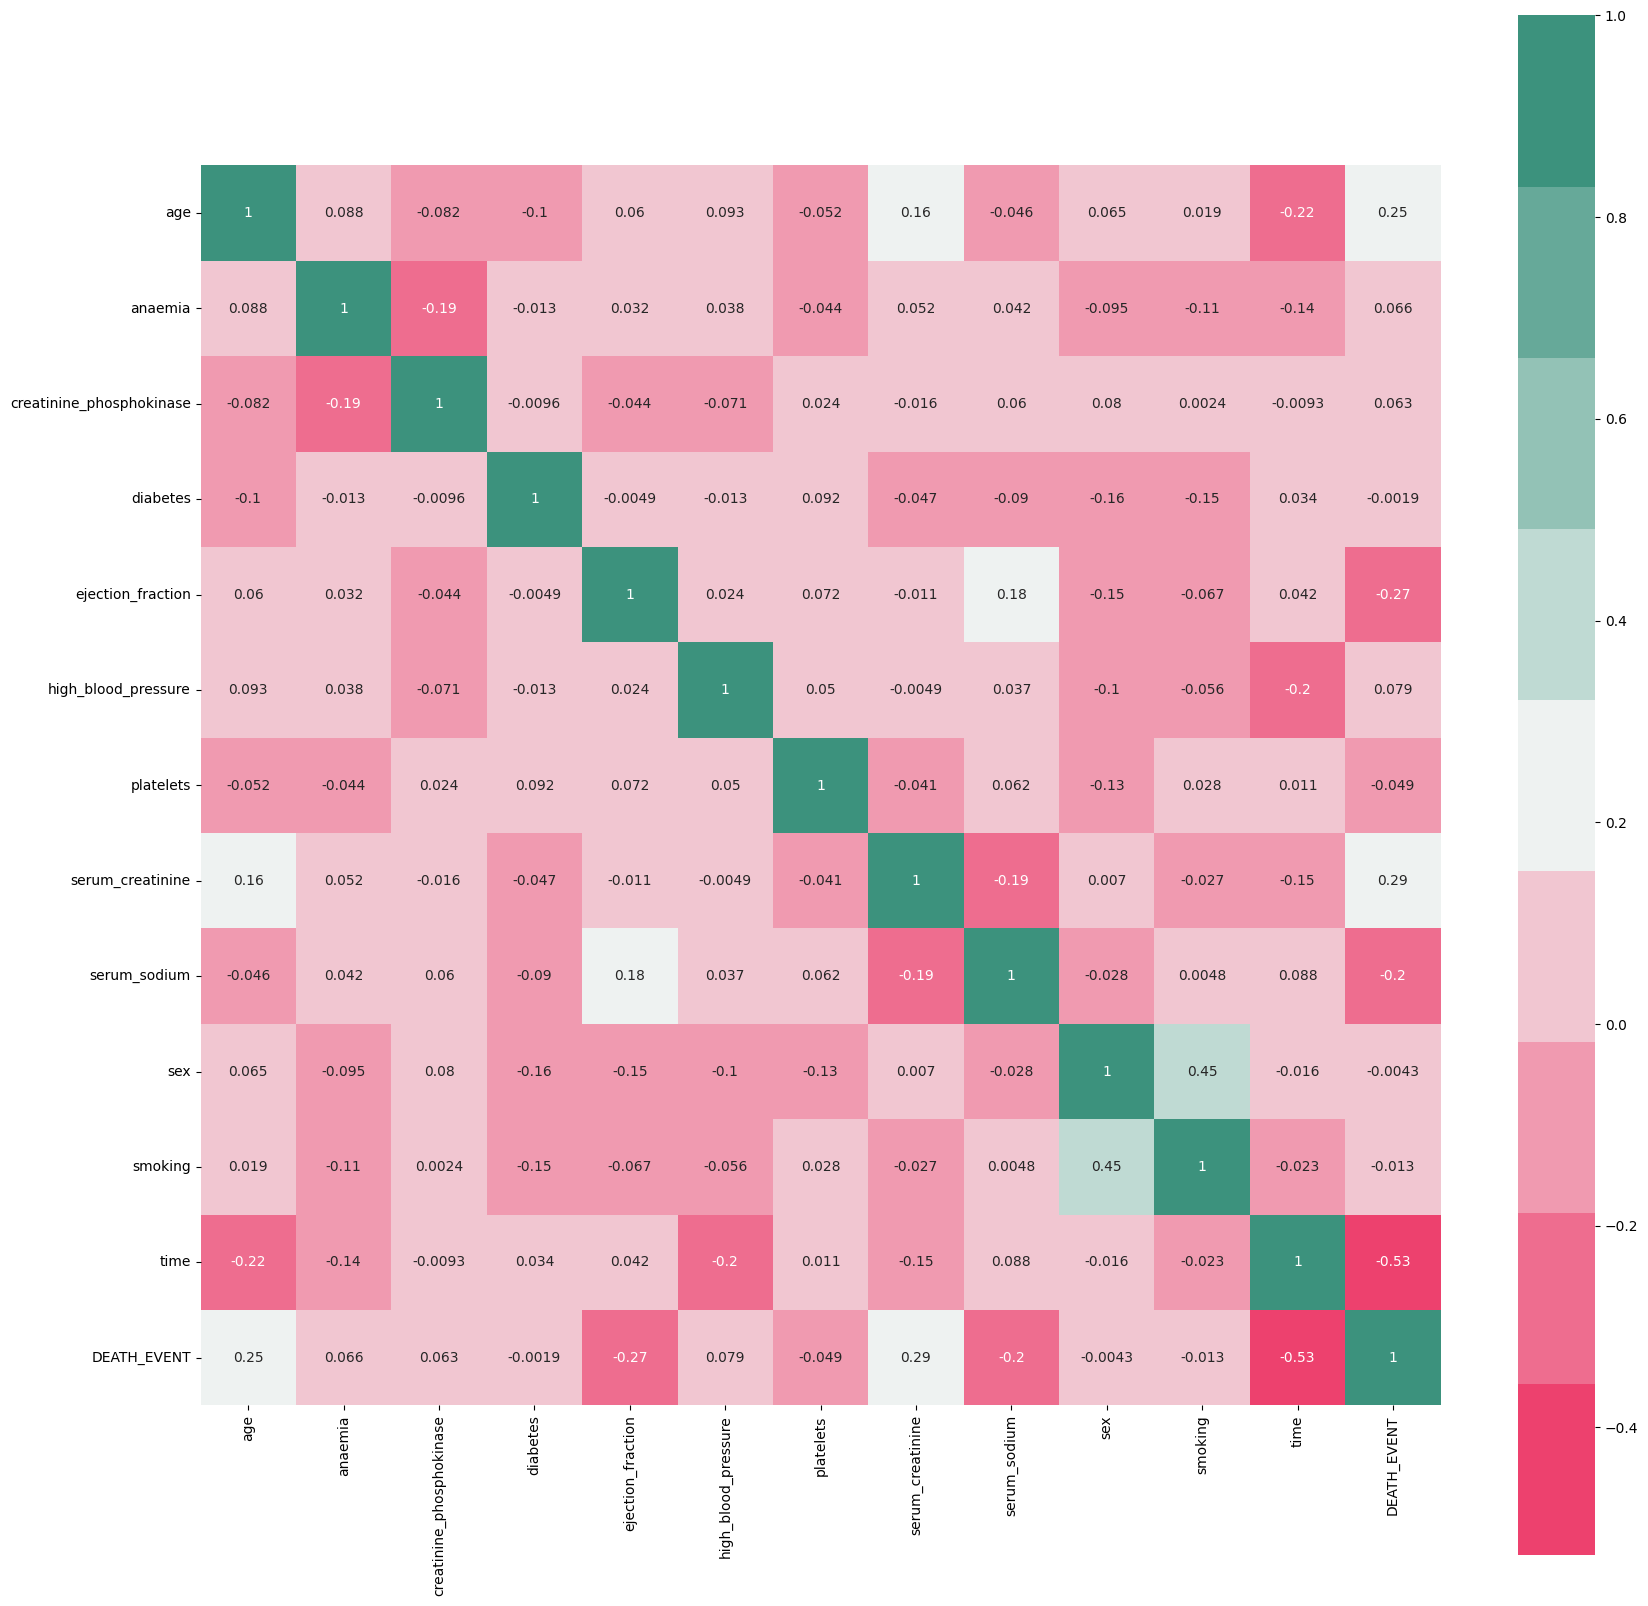

In [11]:
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
corrmat = df.corr()
plt.subplots(figsize=(20, 20))
sns.heatmap(corrmat, cmap=cmap, annot=True, square=True)

# Mengevaluasi Distribusi umuer sehubungan dengan kematian

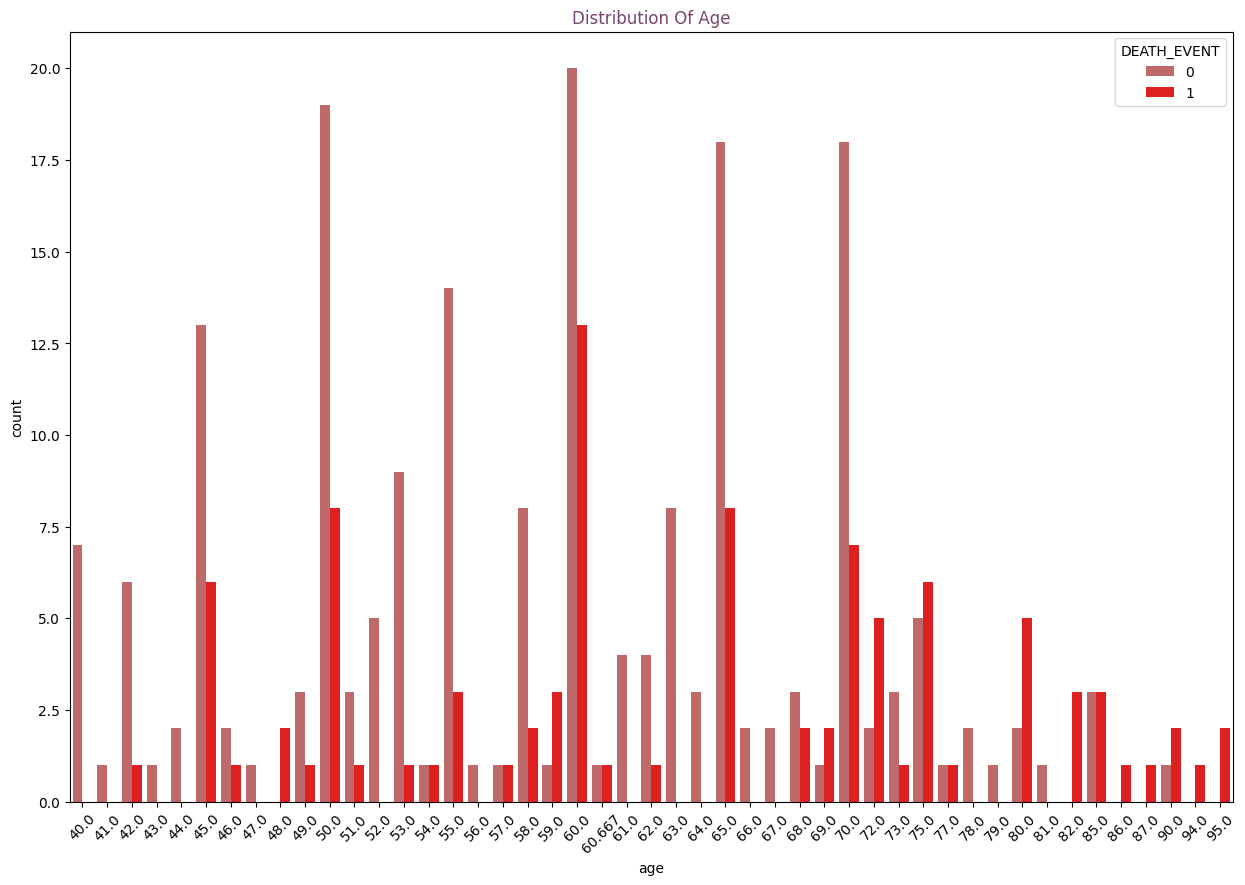

In [12]:
plt.figure(figsize=(15, 10))
Days_of_week = sns.countplot(x=df['age'], hue=df["DEATH_EVENT"], palette=cols)
Days_of_week.set_title("Distribution Of Age", color="#774571")

plt.xticks(rotation=45)

plt.show()

# Mengecek Kemungkinan Terjadi Outliers Menggunakan "Boxen and Swarm Plots" dari Fitur Non-Binary

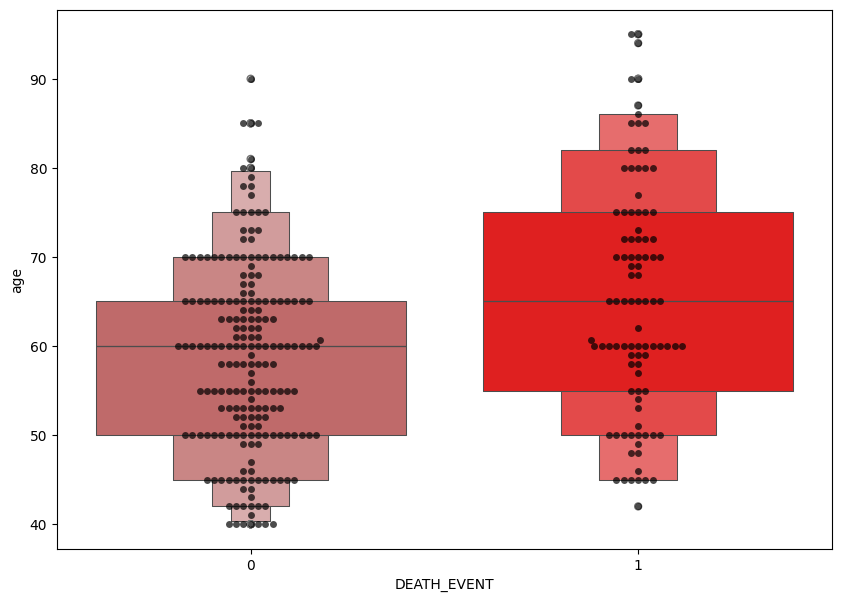

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


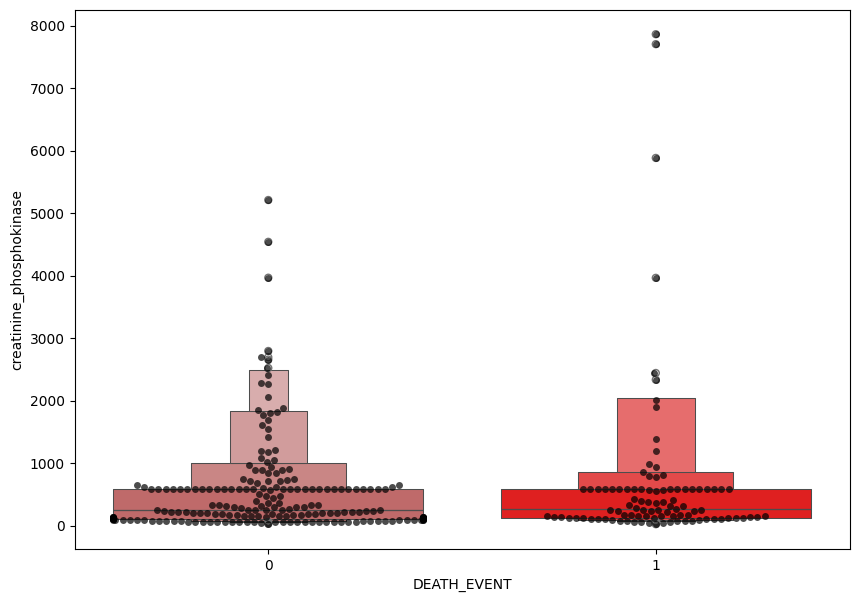

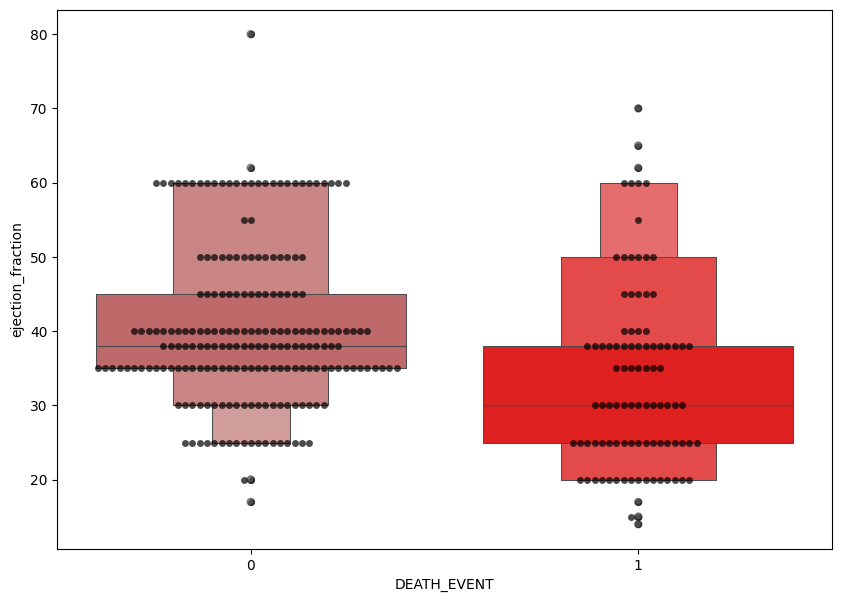

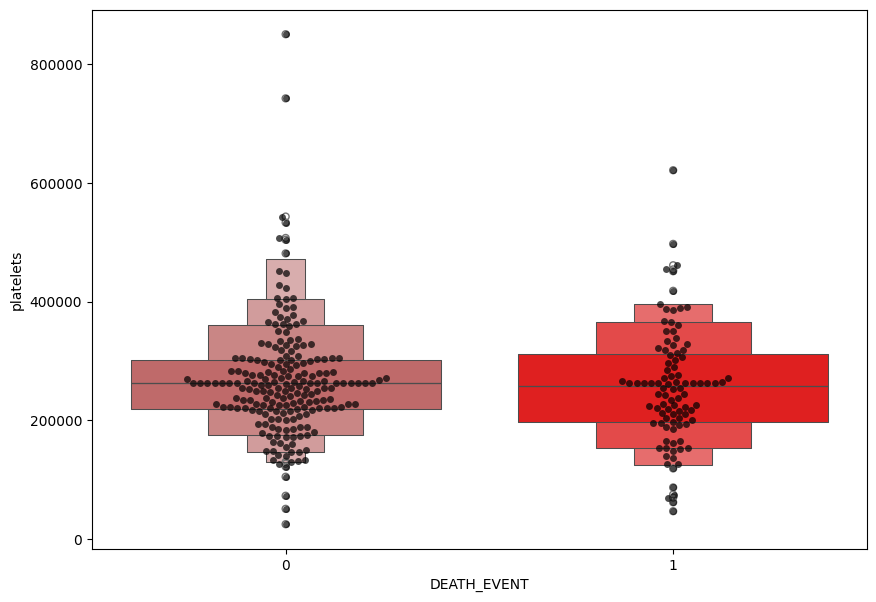

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


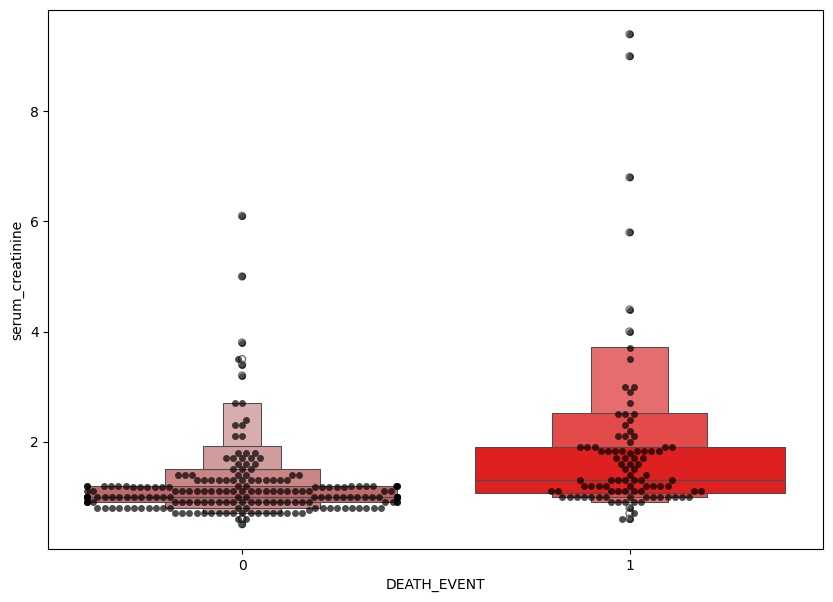

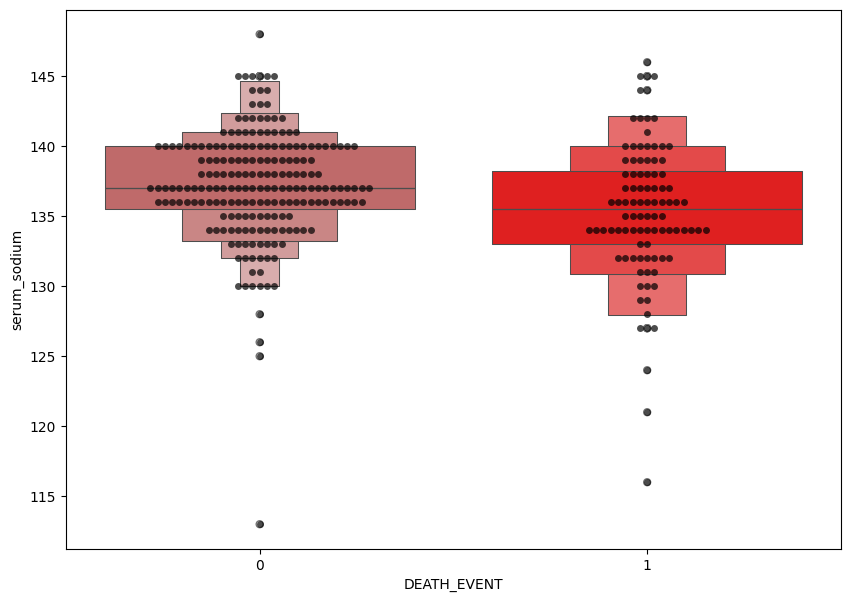

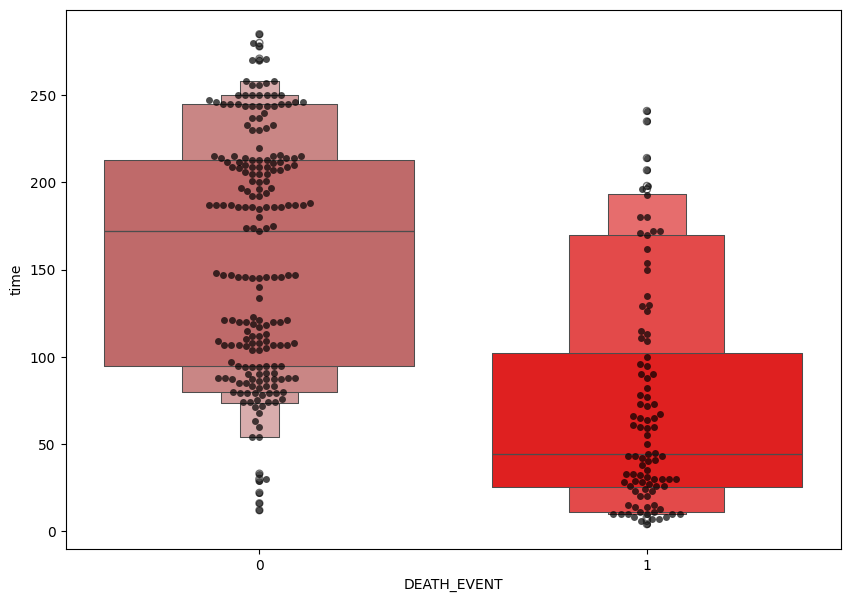

In [13]:
features = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets", "serum_creatinine", "serum_sodium", "time"]

for feature in features:
    plt.figure(figsize=(10, 7))
    sns.swarmplot(x=df["DEATH_EVENT"], y=df[feature], color="black", alpha=0.7)
    sns.boxenplot(x=df["DEATH_EVENT"], y=df[feature], hue=df["DEATH_EVENT"], palette=cols, legend = False)

    plt.show()

# Melakukan Plotting Kernel Density Estimation (KDE Plot) terkait fitur waktu dan umur

<Axes: xlabel='time', ylabel='age'>

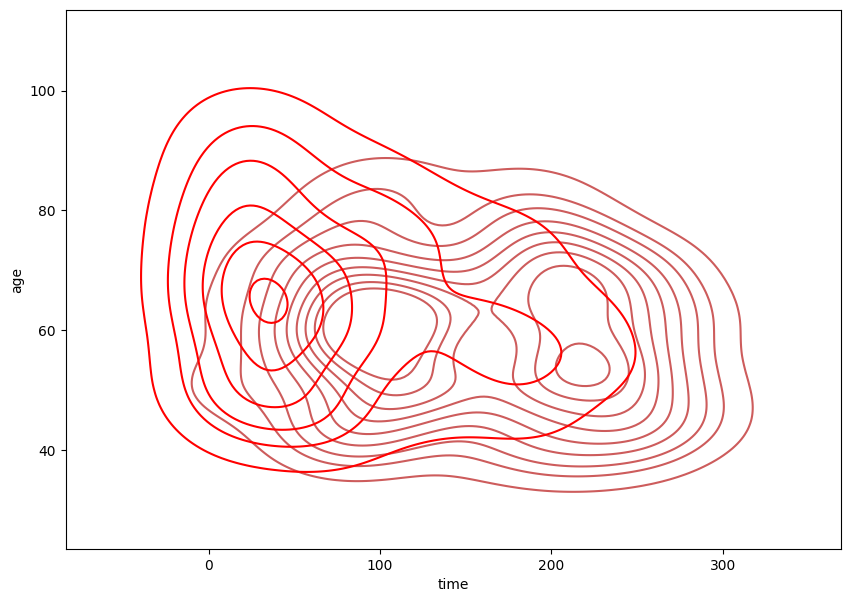

In [14]:
plt.figure(figsize=(10, 7))
sns.kdeplot(x=df["time"], y=df["age"], hue=df["DEATH_EVENT"], palette=cols, legend=False)

# Mendefinisikan Atribut Independent dan Dependent pada Training dan Test Set

In [15]:
X = df.drop(["DEATH_EVENT"], axis=1)
y = df["DEATH_EVENT"]

# Menyiapkan Scaler Standard untuk Fitur dan Menganalisis Data yang Diskalakan

In [16]:
col_names = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled = s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_names)

# menganalisis data yang telah di skala
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


# Melakukan Plot Fitur yang telah Di Skala menggunakan Boxen Plots

<ipython-input-17-0f12e140572b>:3: UserWarning: 
The palette list has fewer values (5) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.boxenplot(data=X_scaled, palette=colors)


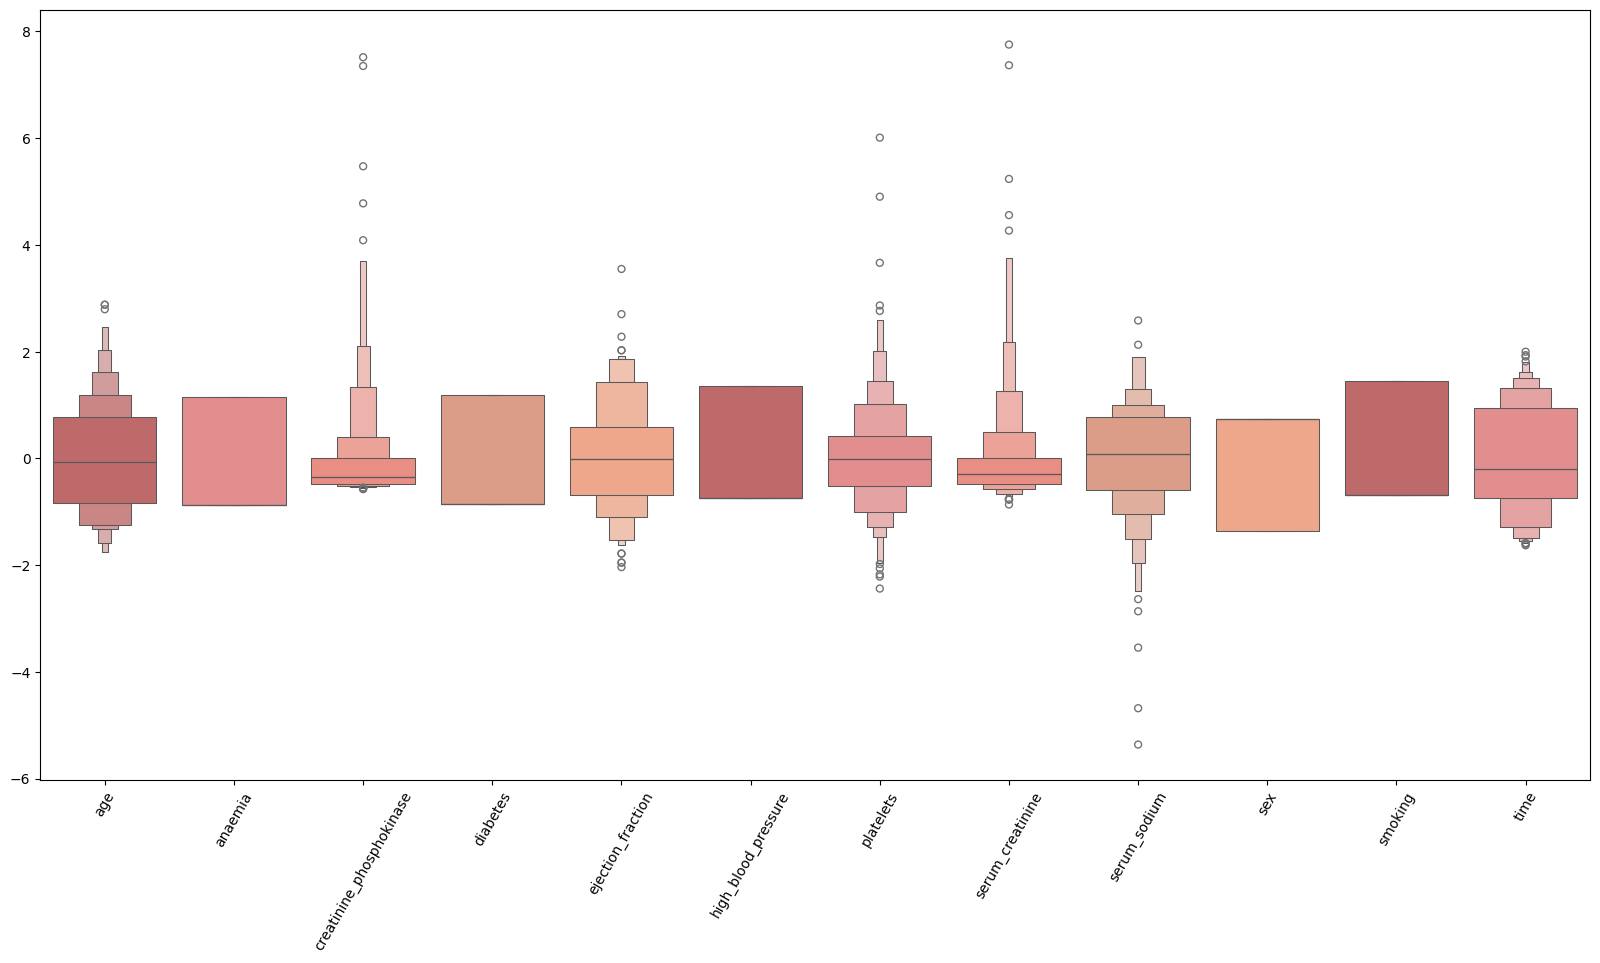

In [17]:
colors = ["#CD5C5C", "#F08080", "#FA8072", "#E9967A", "#FFA07A"]
plt.figure(figsize=(20, 10))
sns.boxenplot(data=X_scaled, palette=colors)
plt.xticks(rotation=60)
plt.show()

# Membagi Variabel ke dalam Training dan Test Set

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=25)

# Support Vector Machine (SVM)

In [19]:
# Instantiating the Support Vector Machine (SVM) algorithm
# The dataset is sourced from: https://www.kaggle.com/andrewmvd/heart-failure-clinical-data
model1 = svm.SVC()

# Fitting the SVM model
model1.fit(X_train, y_train)

# Predicting the test variables
y_pred = model1.predict(X_test)

# Getting the accuracy score
accuracy = model1.score(X_test, y_test)
print(f"Accuracy of the SVM model: {accuracy}")

Accuracy of the SVM model: 0.7888888888888889


In [20]:
# melihat hasil klasifikasi untuk mengevaluasi performa model
classification_report_result = classification_report(y_test, y_pred)
print("Classification Report:")
print(classification_report_result)

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84        60
           1       0.69      0.67      0.68        30

    accuracy                           0.79        90
   macro avg       0.76      0.76      0.76        90
weighted avg       0.79      0.79      0.79        90



<Axes: >

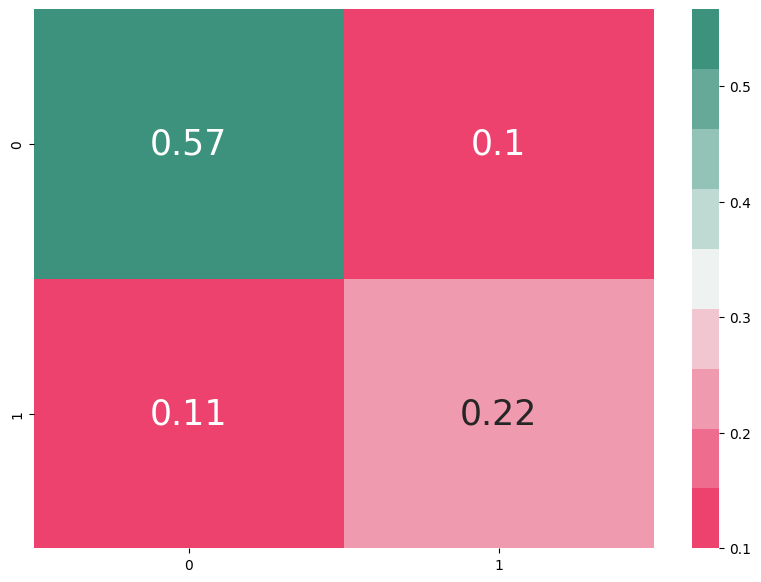

In [21]:
# Getting the confusion matrix for further evaluation
cmap1 = sns.diverging_palette(2, 165, s=80, l=55, n=9)
plt.subplots(figsize=(10, 7))

# Calculating and plotting the confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix / np.sum(cf_matrix), cmap=cmap1, annot=True, annot_kws={'size': 25})

# Artificial Neural Network (ANN)

In [22]:
# Setting up early stopping callback
# The dataset is sourced from: https://www.kaggle.com/andrewmvd/heart-failure-clinical-data
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,  # minimum amount of change to count as an improvement
    patience=20,  # how many epochs to wait before stopping
    restore_best_weights=True
)

# Initializing the Neural Network (NN)
model = Sequential()

# Adding layers to the NN
model.add(Dense(units=16, kernel_initializer='uniform', activation='relu', input_dim=12))
model.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

# Compiling the NN
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training the NN
history = model.fit(X_train, y_train, batch_size=25, epochs=50, callbacks=[early_stopping], validation_split=0.25)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.4114 - loss: 0.6932 - val_accuracy: 0.8302 - val_loss: 0.6919
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6377 - loss: 0.6925 - val_accuracy: 0.8302 - val_loss: 0.6897
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6337 - loss: 0.6916 - val_accuracy: 0.8302 - val_loss: 0.6875
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6089 - loss: 0.6909 - val_accuracy: 0.8302 - val_loss: 0.6851
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6172 - loss: 0.6900 - val_accuracy: 0.8302 - val_loss: 0.6826
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6562 - loss: 0.6882 - val_accuracy: 0.8302 - val_loss: 0.6800
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6449 - loss: 0.6869 - val_accuracy: 0.8302 - val_loss: 0.6773
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5995 - loss: 0.6880 - val_accuracy: 0.8302 - val_loss: 0.6745
Epoch 9/50
